In [ ]:
%gui qt6

# Plotting stuff
import pyqtgraph as pg
import matplotlib.pyplot as plt

from astropy.time import Time
import astropy.units as u

# General stuff
import logging
import sys

# zHunter stuff
from zhunter.photometry import PhotometricPoint
from zhunter.conversions import ergscm2AA


# Logging
log = logging.getLogger(__name__)
logging.basicConfig(stream=sys.stdout, level=logging.DEBUG,
    format="%(asctime)s.%(msecs)03d | %(levelname)-8s | %(funcName)s - %(filename)s:%(lineno)d : %(message)s",

                   )
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("PIL").setLevel(logging.WARNING)

# Photometric data point

In [ ]:

cases = {
    "ABmag": PhotometricPoint(mag=22*u.ABmag, unc=1*u.mag, phot_filter="LSST_u"),
    "ABmag lim": PhotometricPoint(mag=21.5*u.ABmag, unc=0*u.mag, limit=True, phot_filter="LSST_g"),
    "Fnu": PhotometricPoint(mag=10*u.uJy, unc=2*u.uJy, phot_filter="LSST_r"),
    "Fnu lim": PhotometricPoint(mag=15*u.uJy, unc=0*u.uJy, limit=True, phot_filter="LSST_i"),
    "Flam": PhotometricPoint(mag=4e-18*ergscm2AA, unc=1e-18*ergscm2AA, phot_filter="LSST_z"),
    "Flam lim": PhotometricPoint(mag=1e-17*ergscm2AA, unc=0*u.mag, limit=True, phot_filter="LSST_y"),
}


# Plotting

## Spectral plot

In [3]:
# Custom plotting widget
from zhunter.OneDGraphicsWidget import OneDSpectralWidget
wdg = OneDSpectralWidget()
wdg.set_up_plot()
vb = wdg.ax1D.vb
wdg.show()

2024-11-04 15:05:14,314.314 | INFO     | set_up_plot - OneDGraphicsWidget.py:64 : Setting up a new plot called '1D'


In [ ]:
for case, pdp in cases.items():
    pdp.plot_pyqt(vb=vb, mode="spectral", units={"wvlg":u.AA, "flux":1e-17*ergscm2AA}, show_violin=True)

2024-11-04 15:05:14,498.498 | DEBUG    | create_visual_representation - photometry.py:293 : Creating visual representation of photometric data point
2024-11-04 15:05:14,499.499 | DEBUG    | create_errorbar - photometry.py:382 : Creating error bar for photometric data point
2024-11-04 15:05:14,499.499 | DEBUG    | create_errorbar - photometry.py:412 : x, xerr = 3.670e+03, 4.000e+02
2024-11-04 15:05:14,499.499 | DEBUG    | convert_flux_with_unc_propagation - conversions.py:71 : Converting flux from mag(AB) to 1e-17 erg / (Angstrom s cm2).
2024-11-04 15:05:14,501.501 | DEBUG    | convert_flux_with_unc_propagation - conversions.py:100 : Using Monte Carlo sampling for error propagation.
2024-11-04 15:05:14,503.503 | DEBUG    | create_errorbar - photometry.py:427 : y, yerr = 1.281e+00, [[0.7983]
 [1.7835]]
2024-11-04 15:05:14,505.505 | DEBUG    | create_visual_representation - photometry.py:335 : Adding violin plot to photometric data point visual representation
2024-11-04 15:05:14,505.505 |

2024-11-04 15:05:23,341.341 | DEBUG    | create_visual_representation - photometry.py:293 : Creating visual representation of photometric data point
2024-11-04 15:05:23,343.343 | DEBUG    | create_errorbar - photometry.py:382 : Creating error bar for photometric data point
2024-11-04 15:05:23,343.343 | DEBUG    | create_errorbar - photometry.py:412 : x, xerr = 3.670e+03, 4.000e+02
2024-11-04 15:05:23,344.344 | DEBUG    | convert_flux_with_unc_propagation - conversions.py:59 : Both units are the same (mag(AB)), no conversion needed.
2024-11-04 15:05:23,344.344 | DEBUG    | convert_flux_with_unc_propagation - conversions.py:68 : Returning y, yp, ym = 2.200e+01 mag(AB), 1.000e+00 mag, 1.000e+00 mag
2024-11-04 15:05:23,345.345 | DEBUG    | create_errorbar - photometry.py:427 : y, yerr = 2.200e+01, [[1.]
 [1.]]
2024-11-04 15:05:23,347.347 | DEBUG    | create_visual_representation - photometry.py:335 : Adding violin plot to photometric data point visual representation
2024-11-04 15:05:23,348

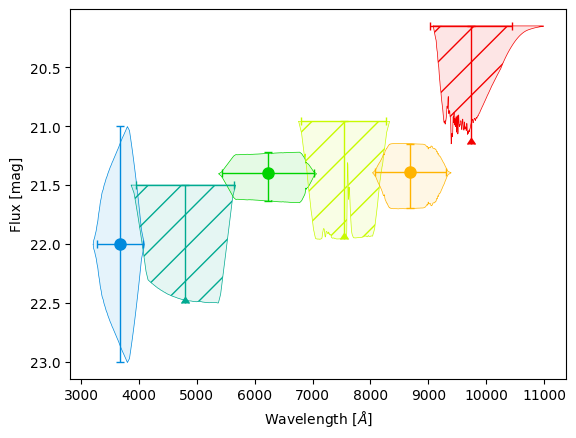

In [6]:
fig, ax = plt.subplots()
for case, pdp in cases.items():
    pdp.plot_mpl(ax=ax, mode="spectral", units={"wvlg":u.AA, "flux":u.ABmag}, show_violin=True)

ax.set_ylim(ax.get_ylim()[::-1])
ax.set_ylabel(r"Flux [mag]")
ax.set_xlabel(r"Wavelength [$\AA$]")
plt.show()

## Temporal plot

In [16]:
# Custom plotting widget
from zhunter.OneDGraphicsWidget import OneDSpectralWidget
wdg = pg.PlotWidget()
vb = wdg.plotItem.vb
wdg.show()

In [18]:
cases = {
    "ABmag": PhotometricPoint(
        mag=22*u.ABmag,
        unc=1*u.mag,
        phot_filter="LSST_g",
        obs_time=Time(60367.01396, format='mjd'),
        obs_duration=100*u.s,
    ),
    "ABmag lim": PhotometricPoint(
        mag=21.5*u.ABmag,
        unc=0*u.mag,
        limit=True,
        phot_filter="LSST_g",
        obs_time=Time(60367.01996, format='mjd'),
        obs_duration=200*u.s,
    ),
    "Fnu": PhotometricPoint(
        mag=10*u.uJy,
        unc=2*u.uJy,
        phot_filter="LSST_r",
        obs_time=Time(60367.01396, format='mjd'),
        obs_duration=100*u.s,
        ),
    "Fnu lim": PhotometricPoint(
        mag=15*u.uJy,
        unc=0*u.uJy,
        limit=True, 
        phot_filter="LSST_r",
        obs_time=Time(60367.01996, format='mjd'),
        obs_duration=200*u.s,
        ),
    "Flam": PhotometricPoint(
        mag=4e-18*ergscm2AA,
        unc=1e-18*ergscm2AA,
        phot_filter="LSST_z",
        obs_time=Time(60367.01396, format='mjd'),
        obs_duration=100*u.s,
        ),
    "Flam lim": PhotometricPoint(
        mag=1e-17*ergscm2AA,
        unc=0*u.mag,
        limit=True, 
        phot_filter="LSST_z",
        obs_time=Time(60367.01996, format='mjd'),
        obs_duration=200*u.s,
        ),
}

In [17]:
for case, pdp in cases.items():
    pdp.plot_pyqt(vb=vb, mode="temporal", units={"wvlg":u.d, "flux":1e-17*ergscm2AA}, show_violin=False)


2024-11-04 15:38:55,395.395 | DEBUG    | create_visual_representation - photometry.py:293 : Creating visual representation of photometric data point
2024-11-04 15:38:55,396.396 | DEBUG    | create_errorbar - photometry.py:382 : Creating error bar for photometric data point
2024-11-04 15:38:55,396.396 | WARNING  | create_errorbar - photometry.py:405 : Temporal mode not yet implemented. Only plotting as a function of MJD.
2024-11-04 15:38:55,403.403 | DEBUG    | create_errorbar - photometry.py:412 : x, xerr = 6.037e+04, 5.787e-04
2024-11-04 15:38:55,403.403 | DEBUG    | convert_flux_with_unc_propagation - conversions.py:71 : Converting flux from mag(AB) to 1e-17 erg / (Angstrom s cm2).
2024-11-04 15:38:55,404.404 | DEBUG    | convert_flux_with_unc_propagation - conversions.py:100 : Using Monte Carlo sampling for error propagation.
2024-11-04 15:38:55,406.406 | DEBUG    | create_errorbar - photometry.py:427 : y, yerr = 7.488e-01, [[0.4638]
 [1.0969]]
2024-11-04 15:38:55,409.409 | DEBUG   

2024-11-04 15:40:57,215.215 | DEBUG    | create_visual_representation - photometry.py:293 : Creating visual representation of photometric data point
2024-11-04 15:40:57,216.216 | DEBUG    | create_errorbar - photometry.py:382 : Creating error bar for photometric data point
2024-11-04 15:40:57,216.216 | WARNING  | create_errorbar - photometry.py:405 : Temporal mode not yet implemented. Only plotting as a function of MJD.
2024-11-04 15:40:57,217.217 | DEBUG    | create_errorbar - photometry.py:412 : x, xerr = 6.037e+04, 5.787e-04
2024-11-04 15:40:57,217.217 | DEBUG    | convert_flux_with_unc_propagation - conversions.py:59 : Both units are the same (mag(AB)), no conversion needed.
2024-11-04 15:40:57,217.217 | DEBUG    | convert_flux_with_unc_propagation - conversions.py:68 : Returning y, yp, ym = 2.200e+01 mag(AB), 1.000e+00 mag, 1.000e+00 mag
2024-11-04 15:40:57,218.218 | DEBUG    | create_errorbar - photometry.py:427 : y, yerr = 2.200e+01, [[1.]
 [1.]]
2024-11-04 15:40:57,220.220 | DE

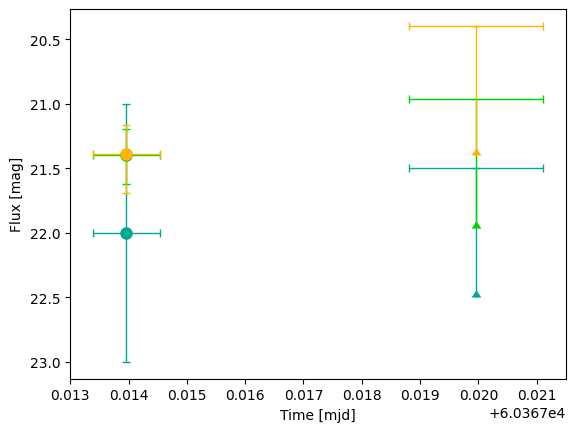

In [22]:
fig, ax = plt.subplots()
for case, pdp in cases.items():
    pdp.plot_mpl(ax=ax, mode="temporal", units={"flux":u.ABmag}, show_violin=False)
ax.set_ylabel(r"Flux [mag]")
ax.set_xlabel(r"Time [mjd]")
ax.set_ylim(ax.get_ylim()[::-1])
plt.show()